# Installations

In [ ]:
!PIP_REQUIRE_VIRTUALENV=false pip install numpy-financial

In [ ]:
!PIP_REQUIRE_VIRTUALENV=false pip install pysr --ignore-requires

In [ ]:
!PIP_REQUIRE_VIRTUALENV=false pip install --upgrade gradio tomlkit typer urllib3

In [ ]:
!PIP_REQUIRE_VIRTUALENV=false pip install -U scikit-fuzzy

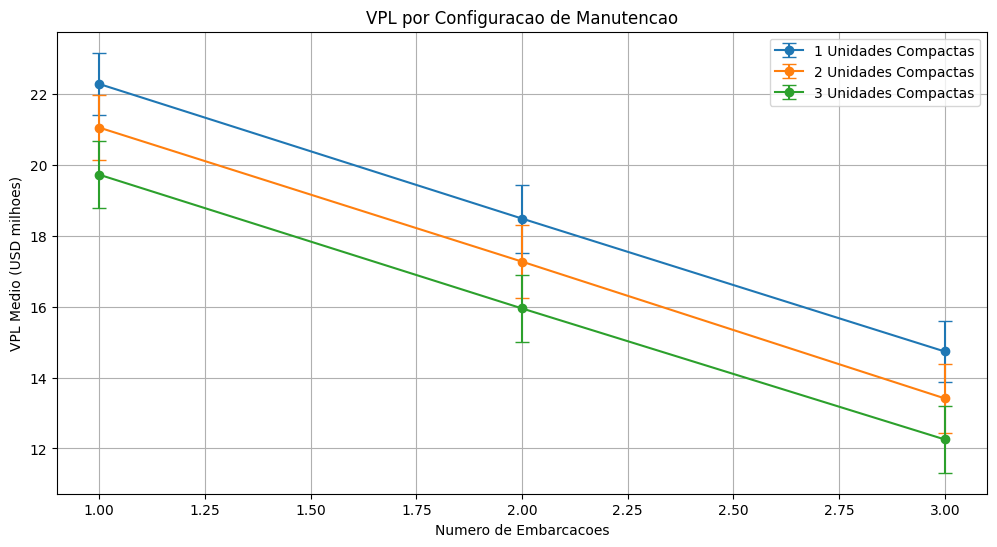

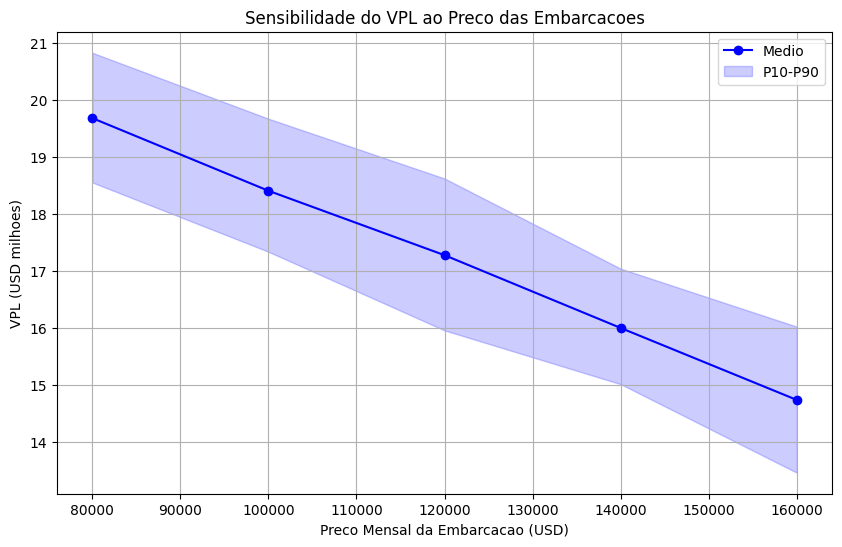

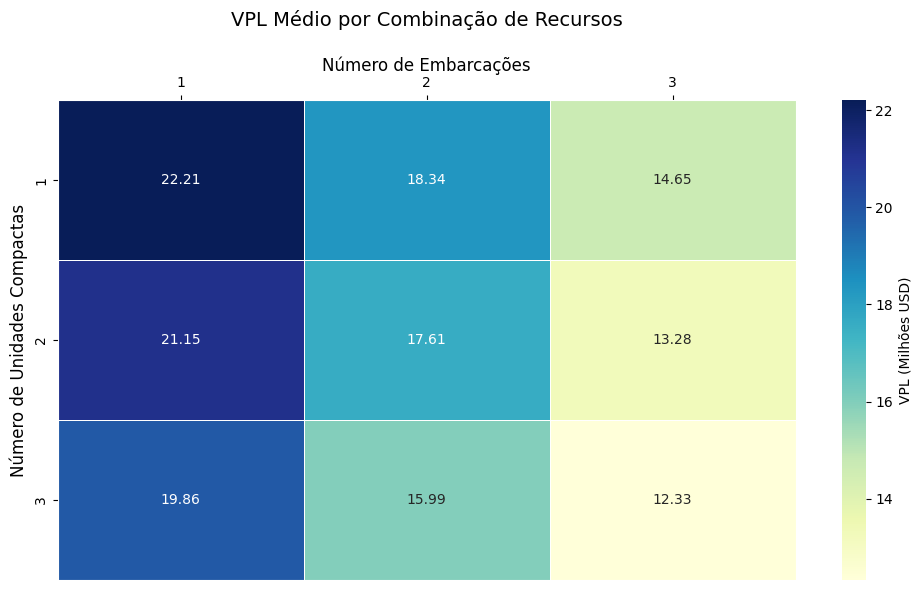

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf
from scipy.stats import triang
from itertools import product
import seaborn as sns

# 1. Geracao de dados dos pocos
np.random.seed(42)
n_pocos = 10
meses = 36
preco_oleo = 40  # USD/bbl
taxa_desconto = 0.1  # 10% ao ano

# Curvas de producao sinteticas
pocos = pd.DataFrame({
    'Poco': [f'P-{i}' for i in range(1, n_pocos+1)],
    'Prod_inicial': np.random.lognormal(8, 0.3, n_pocos),
    'Declinio': np.random.uniform(0.01, 0.005, n_pocos),
    'WC_inicial': np.random.uniform(0.1, 0.5, n_pocos),
    'WC_grad': np.random.uniform(0.005, 0.015, n_pocos)
})

# 2. Funcao de probabilidade de bloqueio
def prob_bloqueio(wc):
    return np.clip((wc - 0.2) * 0.5, 0, 0.7)

# 3. Classes de simulacao
class UnidadeManutencao:
    def __init__(self, tipo, custo_mensal, prob_tempo):
        self.tipo = tipo
        self.custo = custo_mensal
        self.prob_tempo = prob_tempo
        self.disponivel = True
        self.tempo_restante = 0
    
    def alocar(self):
        if self.disponivel:
            self.disponivel = False
            self.tempo_restante = np.random.choice(len(self.prob_tempo), p=self.prob_tempo) + 1
            return True
        return False
    
    def atualizar(self):
        if self.tempo_restante > 0:
            self.tempo_restante -= 1
            if self.tempo_restante == 0:
                self.disponivel = True

class SistemaManutencao:
    def __init__(self, n_embarcacoes, n_unidades):
        self.embarcacoes = [UnidadeManutencao('Embarcacao', 120000, [0.8, 0.2]) for _ in range(n_embarcacoes)]
        self.unidades = [UnidadeManutencao('Compacta', 40000, [0.4, 0.5, 0.1]) for _ in range(n_unidades)]
        self.fila = []
    
    def solicitar_manutencao(self, poco):
        for unidade in self.embarcacoes + self.unidades:
            if unidade.alocar():
                return unidade.tipo
        self.fila.append(poco)
        return None
    
    def atualizar_estados(self):
        for unidade in self.embarcacoes + self.unidades:
            unidade.atualizar()
        
        while self.fila:
            for unidade in self.embarcacoes + self.unidades:
                if unidade.disponivel and unidade.alocar():
                    poco = self.fila.pop(0)
                    break
            else:
                break

class PocoProdutor:
    def __init__(self, params):
        self.params = params
        self.bloqueado = False
        self.em_manutencao = False
        self.tempo_espera = 0
    
    def atualizar(self, mes, sistema):
        if self.bloqueado and not self.em_manutencao:
            tipo = sistema.solicitar_manutencao(self)
            if tipo:
                self.em_manutencao = True
                self.tempo_espera = 0
            else:
                self.tempo_espera += 1
        
        wc = self.params['WC_inicial'] + self.params['WC_grad'] * mes
        if not self.bloqueado and np.random.rand() < prob_bloqueio(wc):
            self.bloqueado = True
        
        return wc

# 4. Funcao de simulacao
def simular_cenario(n_embarcacoes, n_unidades, preco_embarcacao):
    sistema = SistemaManutencao(n_embarcacoes, n_unidades)
    pocos_objs = [PocoProdutor(p) for _, p in pocos.iterrows()]
    
    producao = np.zeros(meses)
    custos = np.zeros(meses)
    wc_medio = np.zeros(meses)
    
    for mes in range(meses):
        # Atualizar contratacoes
        if mes % 12 == 0:
            sistema.embarcacoes = [UnidadeManutencao('Embarcacao', preco_embarcacao, [0.8, 0.2]) 
                                  for _ in range(n_embarcacoes)]
            sistema.unidades = [UnidadeManutencao('Compacta', 40000, [0.4, 0.5, 0.1]) 
                               for _ in range(n_unidades)]
        
        # Atualizar pocos
        total_prod = 0
        for p in pocos_objs:
            wc = p.atualizar(mes, sistema)
            if not p.bloqueado and not p.em_manutencao:
                prod = p.params['Prod_inicial'] * (1 - p.params['Declinio'])**mes
                total_prod += prod * (1 - wc)
            wc_medio[mes] += wc
        
        producao[mes] = total_prod
        custos[mes] = sum(u.custo for u in sistema.embarcacoes + sistema.unidades)
        sistema.atualizar_estados()
        wc_medio[mes] /= n_pocos
    
    fluxo_caixa = producao * preco_oleo - custos
    vpl = npf.npv(taxa_desconto/12, fluxo_caixa)
    return vpl, producao, custos, wc_medio

 
# 5. Monte Carlo e analise
n_sim = 500
resultados = []

# Testar combinacoes de 1-3 embarcacoes e unidades
for n_emb, n_uni in product(range(1,4), range(1,4)):
    vpls = []
    for _ in range(n_sim):
        vpl, *_ = simular_cenario(n_emb, n_uni, 120000)
        vpls.append(vpl)
    resultados.append({
        'Embarcacoes': n_emb,
        'Unidades': n_uni,
        'VPL_medio': np.mean(vpls),
        'VPL_std': np.std(vpls)
    })

df_resultados = pd.DataFrame(resultados)

# 6. Visualizacao
plt.figure(figsize=(12,6))
for n_uni in range(1,4):
    mask = df_resultados['Unidades'] == n_uni
    plt.errorbar(df_resultados[mask]['Embarcacoes'], 
                 df_resultados[mask]['VPL_medio']/1e6,
                 yerr=df_resultados[mask]['VPL_std']/1e6,
                 label=f'{n_uni} Unidades Compactas',
                 marker='o',
                 capsize=5)
plt.title('VPL por Configuracao de Manutencao')
plt.xlabel('Numero de Embarcacoes')
plt.ylabel('VPL Medio (USD milhoes)')
plt.legend()
plt.grid(True)
plt.show()

# 7. Analise de Sensibilidade
precos_emb = np.linspace(80000, 160000, 5)
sensibilidade = []

for preco in precos_emb:
    vpls = [simular_cenario(2, 2, preco)[0] for _ in range(100)]
    sensibilidade.append({
        'Preco_embarcacao': preco,
        'VPL_medio': np.mean(vpls),
        'VPL_P10': np.percentile(vpls, 10),
        'VPL_P90': np.percentile(vpls, 90)
    })

df_sensibilidade = pd.DataFrame(sensibilidade)

plt.figure(figsize=(10,6))
plt.plot(df_sensibilidade['Preco_embarcacao'], df_sensibilidade['VPL_medio']/1e6, 'b-o', label='Medio')
plt.fill_between(df_sensibilidade['Preco_embarcacao'],
                 df_sensibilidade['VPL_P10']/1e6,
                 df_sensibilidade['VPL_P90']/1e6,
                 alpha=0.2, color='b', label='P10-P90')
plt.title('Sensibilidade do VPL ao Preco das Embarcacoes')
plt.xlabel('Preco Mensal da Embarcacao (USD)')
plt.ylabel('VPL (USD milhoes)')
plt.legend()
plt.grid(True)
plt.show()

# 8. Análise Combinatória de Recursos (Atualizada)
combinations = list(product(range(1,4), range(1,4)))
resultados_comb = []

for n_emb, n_uni in combinations:
    vpls = []
    for _ in range(50):
        vpl, *_ = simular_cenario(n_emb, n_uni, 120000)
        vpls.append(vpl)
    
    resultados_comb.append({
        'Embarcacoes': n_emb,
        'Unidades': n_uni,
        'VPL_Medio': np.mean(vpls)
    })

df_combinacoes = pd.DataFrame(resultados_comb)

# Preparar dados para heatmap
heatmap_data = df_combinacoes.pivot(index='Unidades', columns='Embarcacoes', values='VPL_Medio')

# Plotagem melhorada
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data/1e6, annot=True, fmt=".2f", cmap='YlGnBu',
                 linewidths=.5, cbar_kws={'label': 'VPL (Milhões USD)'})

ax.set_title('VPL Médio por Combinação de Recursos\n', fontsize=14)
ax.set_xlabel('Número de Embarcações', fontsize=12)
ax.set_ylabel('Número de Unidades Compactas', fontsize=12)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Adicionar grade
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color('white')

plt.tight_layout()
plt.show()



VPL Simulado: USD 35.91 milhões


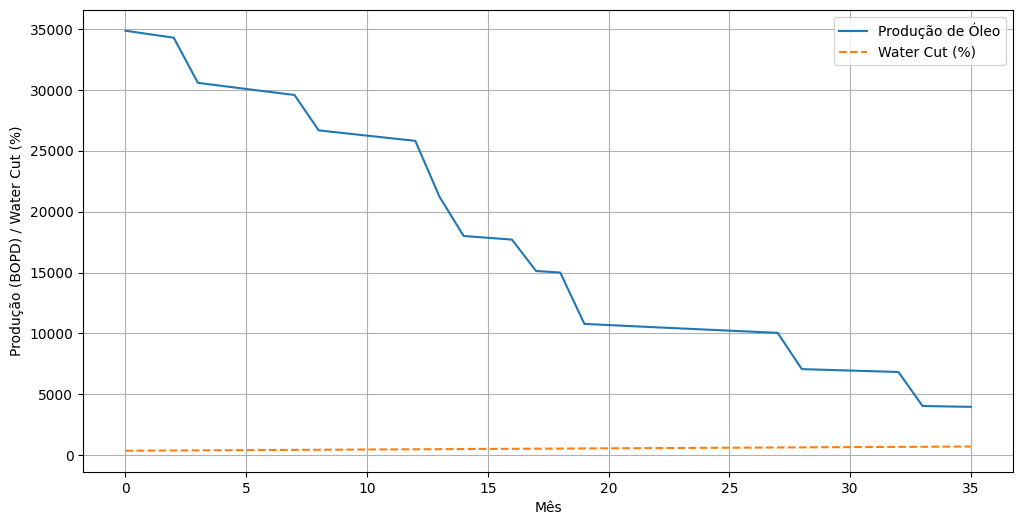

/tmp/ipykernel_568682/2677928739.py:145: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', 3)


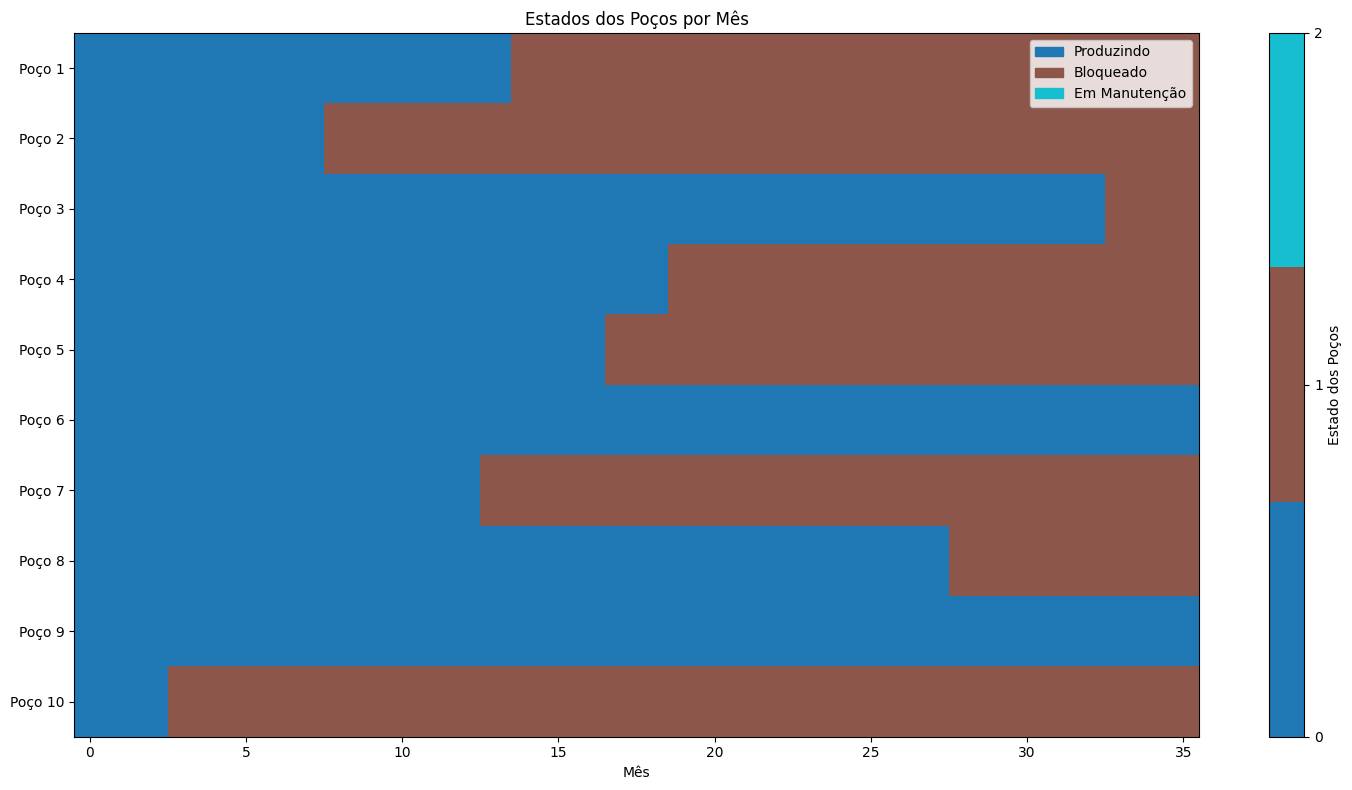

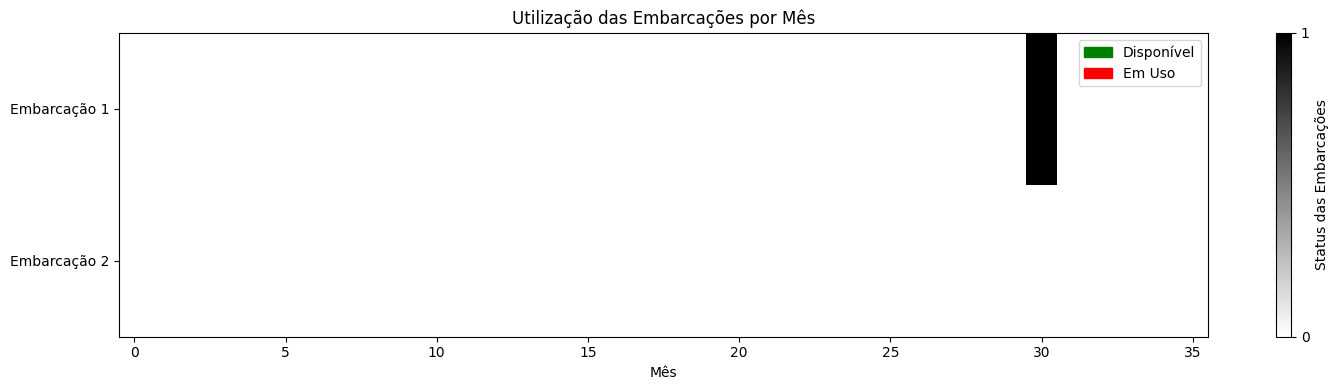

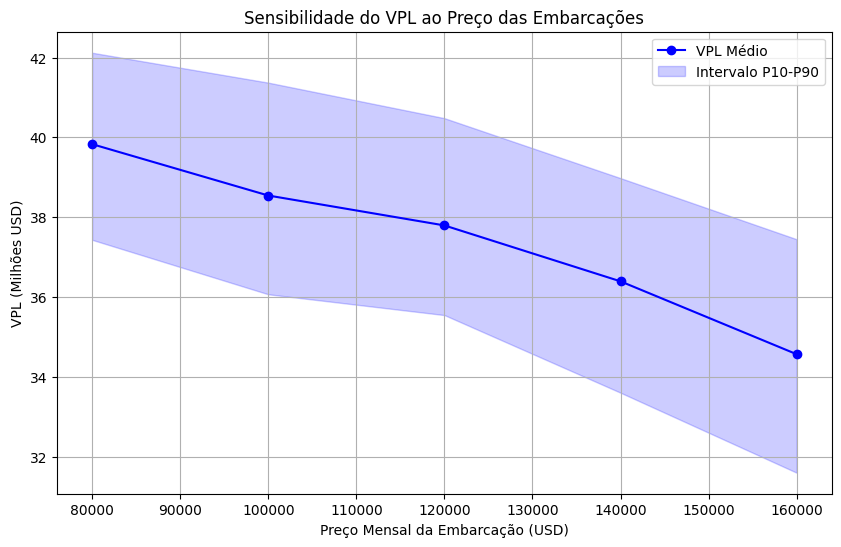

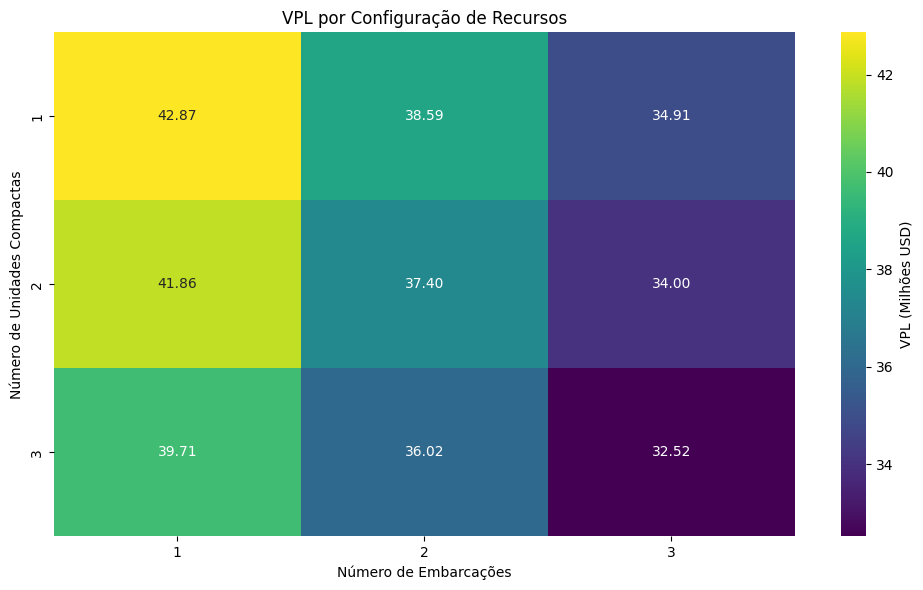

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf
from itertools import product

# 1. Configuração inicial
np.random.seed(42)
n_pocos = 10
meses = 36
preco_oleo = 80  # USD/bbl
taxa_desconto = 0.1  # 10% ao ano

# 2. Geração de dados dos poços
pocos = pd.DataFrame({
    'Poco': [f'P-{i}' for i in range(1, n_pocos+1)],
    'Prod_inicial': np.random.lognormal(8, 0.3, n_pocos),
    'Declinio': np.random.uniform(0.01, 0.005, n_pocos),
    'WC_inicial': np.random.uniform(0.2, 0.6, n_pocos),
    'WC_grad': np.random.uniform(0.005, 0.015, n_pocos)
})

# 3. Classes do sistema
class UnidadeManutencao:
    def __init__(self, tipo, custo_mensal, prob_tempo):
        self.tipo = tipo
        self.custo = custo_mensal
        self.prob_tempo = prob_tempo
        self.disponivel = True
        self.tempo_restante = 0
    
    def alocar(self):
        if self.disponivel:
            self.disponivel = False
            self.tempo_restante = np.random.choice(len(self.prob_tempo), p=self.prob_tempo) + 1
            return True
        return False
    
    def atualizar(self):
        if self.tempo_restante > 0:
            self.tempo_restante -= 1
            if self.tempo_restante == 0:
                self.disponivel = True

class SistemaManutencao:
    def __init__(self, n_embarcacoes, n_unidades):
        self.embarcacoes = [UnidadeManutencao('Embarcacao', 120000, [0.8, 0.2]) for _ in range(n_embarcacoes)]
        self.unidades = [UnidadeManutencao('Compacta', 40000, [0.4, 0.5, 0.1]) for _ in range(n_unidades)]
        self.fila = []
    
    def solicitar_manutencao(self, poco):
        for unidade in self.embarcacoes + self.unidades:
            if unidade.alocar():
                return unidade.tipo
        self.fila.append(poco)
        return None
    
    def atualizar_estados(self):
        for unidade in self.embarcacoes + self.unidades:
            unidade.atualizar()
        
        while self.fila:
            for unidade in self.embarcacoes + self.unidades:
                if unidade.disponivel and unidade.alocar():
                    poco = self.fila.pop(0)
                    break
            else:
                break

class PocoProdutor:
    def __init__(self, params):
        self.params = params
        self.bloqueado = False
        self.em_manutencao = False
        self.tempo_espera = 0
    
    def atualizar(self, mes, sistema):
        if self.bloqueado and not self.em_manutencao:
            tipo = sistema.solicitar_manutencao(self)
            if tipo:
                self.em_manutencao = True
                self.tempo_espera = 0
            else:
                self.tempo_espera += 1
        
        wc = self.params['WC_inicial'] + self.params['WC_grad'] * mes
        if not self.bloqueado and np.random.rand() < ((wc - 0.5) * 3 if wc > 0.5 else 0):
            self.bloqueado = True
        
        return wc

# 4. Função de simulação corrigida
def simular_cenario(n_embarcacoes, n_unidades, preco_embarcacao):
    sistema = SistemaManutencao(n_embarcacoes, n_unidades)
    pocos_objs = [PocoProdutor(p) for _, p in pocos.iterrows()]
    
    registro_pocos = np.zeros((n_pocos, meses), dtype=int)
    registro_embarcacoes = np.zeros((n_embarcacoes, meses), dtype=int)
    
    producao = np.zeros(meses)
    custos = np.zeros(meses)
    wc_medio = np.zeros(meses)
    
    for mes in range(meses):
        if mes % 12 == 0:
            sistema.embarcacoes = [UnidadeManutencao('Embarcacao', preco_embarcacao, [0.8, 0.2]) 
                                  for _ in range(n_embarcacoes)]
        
        # Registrar status das embarcações
        for i, emb in enumerate(sistema.embarcacoes):
            registro_embarcacoes[i, mes] = 0 if emb.disponivel else 1
        
        total_prod = 0
        for i, p in enumerate(pocos_objs):
            wc = p.atualizar(mes, sistema)
            
            # Registrar estado do poço
            if p.bloqueado:
                estado = 1
            elif p.em_manutencao:
                estado = 2
            else:
                estado = 0
            registro_pocos[i, mes] = estado
            
            # Cálculo corrigido da produção
            if not p.bloqueado and not p.em_manutencao:
                prod = max(p.params['Prod_inicial'] * (1 - p.params['Declinio'])**mes, 0)
                total_prod += prod  # Removido o fator (1 - wc)
            
            wc_medio[mes] += wc
        
        producao[mes] = total_prod
        custos[mes] = sum(u.custo for u in sistema.embarcacoes + sistema.unidades)
        sistema.atualizar_estados()
        wc_medio[mes] /= n_pocos
    
    fluxo_caixa = producao * preco_oleo - custos
    vpl = npf.npv(taxa_desconto/12, fluxo_caixa)
    return vpl, producao, custos, wc_medio, registro_pocos, registro_embarcacoes

# 5. Funções de plotagem
def plot_estados_pocos(registro_pocos):
    plt.figure(figsize=(15, 8))
    cmap = plt.cm.get_cmap('tab10', 3)
    plt.imshow(registro_pocos, aspect='auto', cmap=cmap, vmin=0, vmax=2)
    
    plt.colorbar(ticks=[0, 1, 2], label='Estado dos Poços')
    plt.yticks(range(n_pocos), [f'Poço {i+1}' for i in range(n_pocos)])
    plt.xlabel('Mês')
    plt.title('Estados dos Poços por Mês')
    
    labels = ['Produzindo', 'Bloqueado', 'Em Manutenção']
    handles = [plt.Rectangle((0,0),1,1, color=cmap(i)) for i in range(3)]
    plt.legend(handles, labels)
    plt.tight_layout()
    plt.show()

def plot_uso_embarcacoes(registro_embarcacoes):
    plt.figure(figsize=(15, 4))
    plt.imshow(registro_embarcacoes, aspect='auto', cmap='binary', vmin=0, vmax=1)
    
    plt.colorbar(ticks=[0, 1], label='Status das Embarcações')
    plt.yticks(range(len(registro_embarcacoes)), [f'Embarcação {i+1}' for i in range(len(registro_embarcacoes))])
    plt.xlabel('Mês')
    plt.title('Utilização das Embarcações por Mês')
    
    labels = ['Disponível', 'Em Uso']
    handles = [plt.Rectangle((0,0),1,1, color=('green' if i==0 else 'red')) for i in [0,1]]
    plt.legend(handles, labels)
    plt.tight_layout()
    plt.show()

# 6. Execução e visualização
vpl, producao, custos, wc_medio, reg_pocos, reg_emb = simular_cenario(2, 2, 120000)

print(f"VPL Simulado: USD {vpl/1e6:.2f} milhões")

plt.figure(figsize=(12,6))
plt.plot(producao, label='Produção de Óleo')
plt.plot(wc_medio*1000, label='Water Cut (%)', linestyle='--')
plt.xlabel('Mês')
plt.ylabel('Produção (BOPD) / Water Cut (%)')
plt.legend()
plt.grid(True)
plt.show()

plot_estados_pocos(reg_pocos)
plot_uso_embarcacoes(reg_emb)


# 7. Análise de Sensibilidade ao Preço das Embarcações
def analise_sensibilidade(precos_embarcacoes, n_sim=100):
    resultados = []
    
    for preco in precos_embarcacoes:
        vpls = []
        for _ in range(n_sim):
            vpl, *_ = simular_cenario(2, 2, preco)
            vpls.append(vpl)
        
        resultados.append({
            'Preco_Embarcacao': preco,
            'VPL_Medio': np.mean(vpls),
            'VPL_P10': np.percentile(vpls, 10),
            'VPL_P90': np.percentile(vpls, 90)
        })
    
    return pd.DataFrame(resultados)

# Parâmetros da análise de sensibilidade
precos_testes = np.linspace(80000, 160000, 5)  # De USD 80k a 160k
df_sensibilidade = analise_sensibilidade(precos_testes, n_sim=50)

# Plot da análise de sensibilidade
plt.figure(figsize=(10,6))
plt.plot(df_sensibilidade['Preco_Embarcacao'], df_sensibilidade['VPL_Medio']/1e6, 
         'b-o', label='VPL Médio')
plt.fill_between(df_sensibilidade['Preco_Embarcacao'],
                 df_sensibilidade['VPL_P10']/1e6,
                 df_sensibilidade['VPL_P90']/1e6,
                 alpha=0.2, color='b', label='Intervalo P10-P90')

plt.title('Sensibilidade do VPL ao Preço das Embarcações')
plt.xlabel('Preço Mensal da Embarcação (USD)')
plt.ylabel('VPL (Milhões USD)')
plt.legend()
plt.grid(True)
plt.show()

# 8. Análise Combinatória de Recursos
combinations = list(product(range(1,4), range(1,4)))  # 1-3 embarcações e unidades
resultados_comb = []

for n_emb, n_uni in combinations:
    vpls = []
    for _ in range(50):  # Reduzido para 50 simulações por combinação
        vpl, *_ = simular_cenario(n_emb, n_uni, 120000)
        vpls.append(vpl)
    
    resultados_comb.append({
        'Embarcacoes': n_emb,
        'Unidades': n_uni,
        'VPL_Medio': np.mean(vpls),
        'VPL_Std': np.std(vpls)
    })

df_combinacoes = pd.DataFrame(resultados_comb)

# Preparar dados para heatmap
heatmap_data = df_combinacoes.pivot(index='Unidades', columns='Embarcacoes', values='VPL_Medio')

# Plotar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data/1e6, annot=True, fmt=".2f", cmap='viridis', 
            cbar_kws={'label': 'VPL (Milhões USD)'})

plt.title('VPL por Configuração de Recursos')
plt.xlabel('Número de Embarcações')
plt.ylabel('Número de Unidades Compactas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Basic Implementation

[3936524363.8478475, 4025995682.4703717, 3923984554.8665295]
[3897885996.895258, 3938325969.8953986, 3795651979.850893]
[3852986243.369953, 3852090943.97999, 3667324755.851489]
[3805168405.156485, 3764332524.789847, 3539503294.467886]


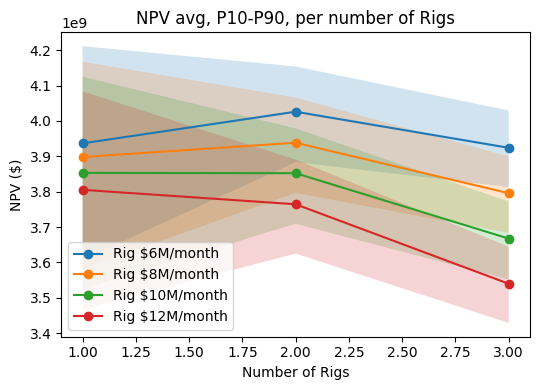

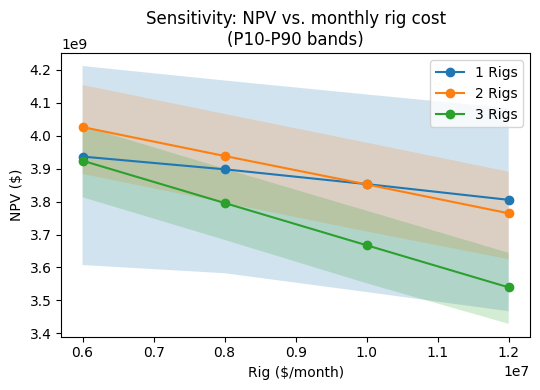

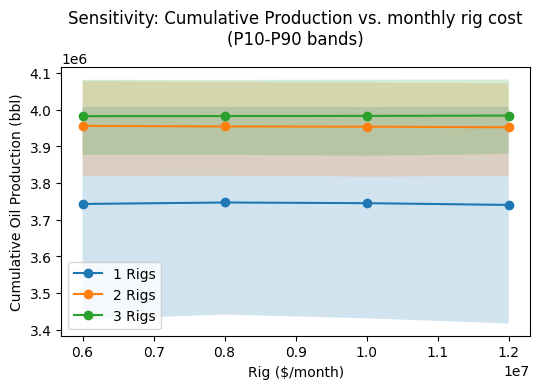

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações iniciais
np.random.seed(1)
n_pocos = 13
n_meses = 24
n_simul = 10000
taxa = 0.01 # taxa de desconto mensal
preco_oleo = 40 # $/bbl

# Curvas sintéticas de produção (vazão de óleo e water cut)
vazao_inicial = np.random.uniform(6500, 35000, n_pocos)
declinio = np.random.uniform(0.003, 0.025, n_pocos)
wc_inicial = np.random.uniform(0.0, 0.5, n_pocos)
wc_final = np.random.uniform(0.6, 0.85, n_pocos)

prod_oleo = np.zeros((n_pocos, n_meses))
water_cut = np.zeros((n_pocos, n_meses))
for i in range(n_pocos):
    prod_oleo[i] = vazao_inicial[i] * np.exp(-declinio[i]*np.arange(n_meses))
    water_cut[i] = np.linspace(wc_inicial[i], wc_final[i], n_meses)

# Probabilidade de bloqueio de linha (linear com water cut)
def prob_bloqueio(wc):
    return wc/8

# Parâmetros de embarcações
precos_embarcacao = [6000000, 8000000, 10000000, 12000000] # $/mês (variação sensibilidade)
meses_contrato = 12

# Probabilidades de tempo de manutenção
prob_embarcacao = [0.75, 0.25] # 1 mês, 2 meses
tempo_embarcacao = [1, 2]

# Estados dos poços
ESTADOS_POCO = {
    0: 'Prod',        # Produzindo normalmente
    1: 'Blocked',    # Bloqueado, aguardando manutenção
    2: 'Workover',   # Em manutenção com embarcação
}
cores_estados_poco = ['#4daf4a', '#e41a1c', '#377eb8']

# Estados das embarcações
ESTADOS_EMB = {
    0: 'Idle',
    1: 'Busy'
}
cores_embarcacao = ['#cccccc', '#377eb8']

def simular(preco_embarcacao, n_embarcacoes):
    # Inicializa contratos
    emb_contrato = [0]*n_embarcacoes # meses restantes

    # Controle explícito das embarcações
    emb_status = [None] * n_embarcacoes  # Para cada embarcação: None ou (poço, meses_restantes)

    # Registro do estado mensal dos poços
    estados_pocos = np.zeros((n_pocos, n_meses), dtype=int)
    # Registro do uso das embarcações
    uso_embarcacao = np.zeros((n_embarcacoes, n_meses), dtype=int)
    # Registro de manutenção em andamento
    manut_iniciada = [None]*n_pocos # None ou ('emb', emb_idx, meses_rest)
    # Registro de VPL
    receitas = np.zeros(n_meses)
    custos = np.zeros(n_meses)

    # Inicializa todos os poços como produzindo no mês 0
    estados_pocos[:,0] = 0

    for mes in range(n_meses):
        # Checa renovação de contratos
        for i in range(n_embarcacoes):
            if mes%meses_contrato==0:
                emb_contrato[i] = meses_contrato

        # Propaga estados do mês anterior se não for o primeiro mês
        if mes > 0:
            estados_pocos[:,mes] = estados_pocos[:,mes-1]

        # Libera embarcações cujas manutenções terminaram neste mês
        for i in range(n_embarcacoes):
            if emb_status[i] is not None:
                poco, meses_rest = emb_status[i]
                uso_embarcacao[i,mes] = 1
                if meses_rest == 1:
                    emb_status[i] = None
                    manut_iniciada[poco] = None
                    estados_pocos[poco, mes] = 0  # volta a produzir imediatamente
                    uso_embarcacao[i,mes] = 0
                else:
                    emb_status[i] = (poco, meses_rest-1)

        # Gera eventos de bloqueio para poços produzindo e sem manutenção
        for p in range(n_pocos):
            if estados_pocos[p,mes] == 0 and manut_iniciada[p] is None:
                if np.random.rand() < prob_bloqueio(water_cut[p,mes]):
                    estados_pocos[p,mes] = 1 # bloqueio

        # Para cada poço bloqueado sem manutenção, tenta alocar uma embarcação livre
        for p in range(n_pocos):
            if estados_pocos[p, mes] == 1 and manut_iniciada[p] is None:
                emb_idx = None
                for i in range(n_embarcacoes):
                    if emb_status[i] is None and emb_contrato[i] > 0:
                        emb_idx = i
                        break
                if emb_idx is not None:
                    tempo = np.random.choice(tempo_embarcacao, p=prob_embarcacao)
                    emb_status[emb_idx] = (p, tempo)
                    manut_iniciada[p] = ('emb', emb_idx, tempo)
                    estados_pocos[p, mes] = 2
                    uso_embarcacao[emb_idx, mes] = 1

        # Receita e custo do mês
        receita_mes = 0
        for p in range(n_pocos):
            if estados_pocos[p,mes] == 0: # produzindo
                receita_mes += prod_oleo[p,mes] * 30 * preco_oleo
        receitas[mes] = receita_mes
        custos[mes] = n_embarcacoes*preco_embarcacao

        # Atualiza contratos
        for i in range(n_embarcacoes):
            emb_contrato[i] -= 1

    # Cálculo do VPL
    fluxo_liq = receitas-custos
    vpl = np.sum(fluxo_liq/((1+taxa)**np.arange(n_meses)))
    prod_acum = np.sum([np.sum(prod_oleo[p,:][estados_pocos[p,:]==0]) for p in range(n_pocos)])
    return vpl, estados_pocos, uso_embarcacao, prod_acum

# Simulações para diferentes cenários de embarcação
cenarios = []
for preco_embarcacao in precos_embarcacao:
    vpl_sim = []
    prodacum_sim = []
    estados_sim = []
    uso_emb_sim = []
    for n_embarcacoes in [1,2,3]:
        vpl_cen = []
        prodacum_cen = []
        for s in range(n_simul):
            vpl, estados_pocos, uso_embarcacao, prod_acum = simular(preco_embarcacao, n_embarcacoes)
            vpl_cen.append(vpl)
            prodacum_cen.append(prod_acum)
            if s==0: # registra só uma simulação para gráficos
                estados_sim.append(estados_pocos)
                uso_emb_sim.append(uso_embarcacao)
        vpl_sim.append(vpl_cen)
        prodacum_sim.append(prodacum_cen)
    cenarios.append({
        'preco': preco_embarcacao,
        'vpls': vpl_sim,
        'prodacum': prodacum_sim,
        'estados': estados_sim,
        'uso_emb': uso_emb_sim
    })

# --- Plot VPL médio por cenário de embarcação e quantidade ---
plt.figure(figsize=(5.5,4))
for idx, c in enumerate(cenarios):
    vpls = c['vpls']
    vpl_medios = [np.mean(v) for v in vpls]
    vpl_p10 = [np.percentile(v, 10) for v in vpls]
    vpl_p90 = [np.percentile(v, 90) for v in vpls]
    print(vpl_medios)
    plt.plot([1,2,3], vpl_medios, marker='o', label=f'Rig ${c["preco"]/1000000:.0f}M/month')
    plt.fill_between([1,2,3], vpl_p10, vpl_p90, alpha=0.2)

plt.xlabel('Number of Rigs')
plt.ylabel('NPV ($)')
plt.title('NPV avg, P10-P90, per number of Rigs')
plt.legend()
plt.tight_layout()
plt.show()

# --- Análise de sensibilidade ao preço da embarcação com faixas P10-P90 ---
plt.figure(figsize=(5.5,4))
for n in range(3):
    vpl_medios = [np.mean(c['vpls'][n]) for c in cenarios]
    vpl_p10 = [np.percentile(c['vpls'][n], 10) for c in cenarios]
    vpl_p90 = [np.percentile(c['vpls'][n], 90) for c in cenarios]

    plt.plot(precos_embarcacao, vpl_medios, marker='o', label=f'{n+1} Rigs')
    plt.fill_between(precos_embarcacao, vpl_p10, vpl_p90, alpha=0.2)

plt.xlabel('Rig ($/month)')
plt.ylabel('NPV ($)')
plt.title('Sensitivity: NPV vs. monthly rig cost\n(P10-P90 bands)')
plt.legend()
plt.tight_layout()
plt.show()


# --- Sensibilidade da produção acumulada ao preço da embarcação (com faixas P10-P90) ---
plt.figure(figsize=(5.5,4))
for n in range(3):
    prodacum_medios = [np.mean(c['prodacum'][n]) for c in cenarios]
    prodacum_p10 = [np.percentile(c['prodacum'][n], 10) for c in cenarios]
    prodacum_p90 = [np.percentile(c['prodacum'][n], 90) for c in cenarios]

    plt.plot(precos_embarcacao, prodacum_medios, marker='o', label=f'{n+1} Rigs')
    plt.fill_between(precos_embarcacao, prodacum_p10, prodacum_p90, alpha=0.2)

plt.xlabel('Rig ($/month)')
plt.ylabel('Cumulative Oil Production (bbl)')
plt.title('Sensitivity: Cumulative Production vs. monthly rig cost\n(P10-P90 bands)')
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_986929/1636266121.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


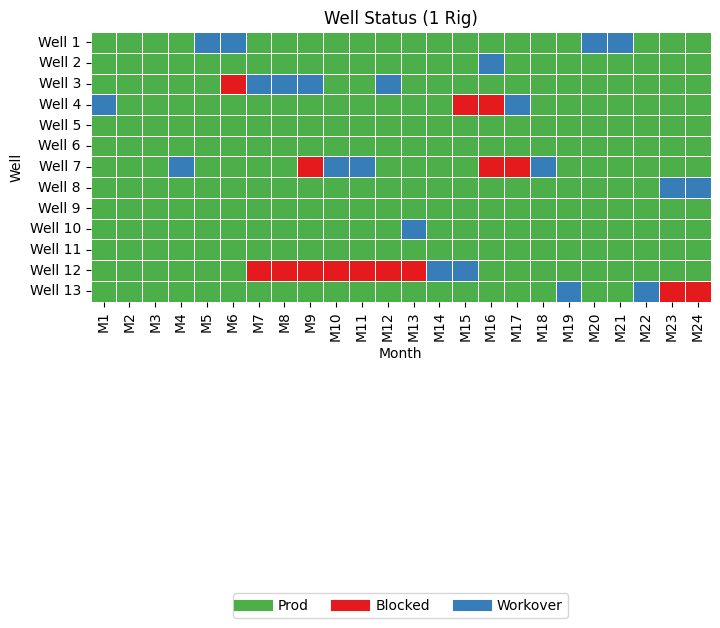

/tmp/ipykernel_986929/1636266121.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


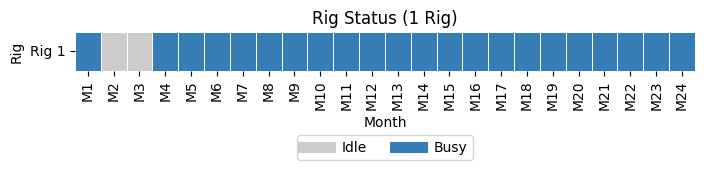

/tmp/ipykernel_986929/1636266121.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


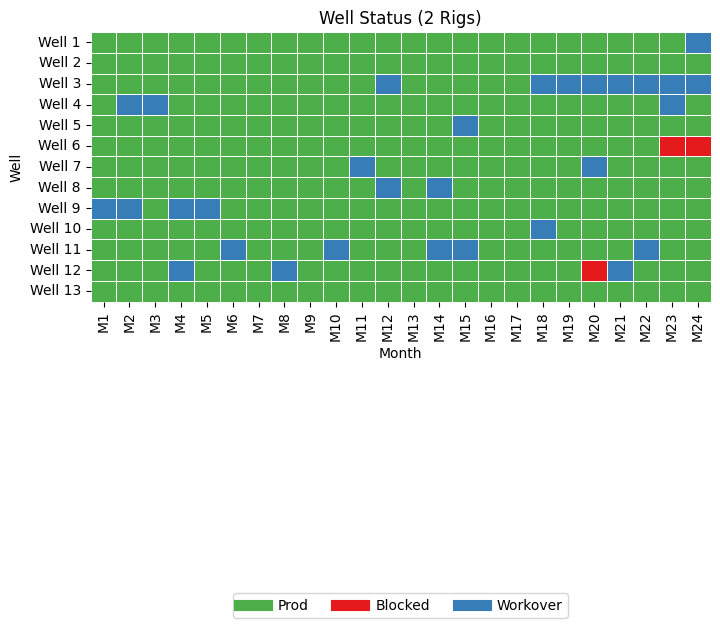

/tmp/ipykernel_986929/1636266121.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


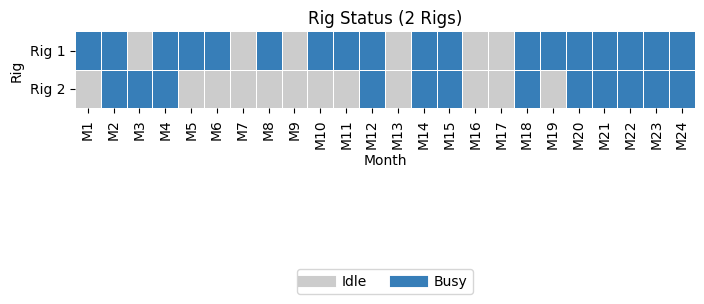

/tmp/ipykernel_986929/1636266121.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


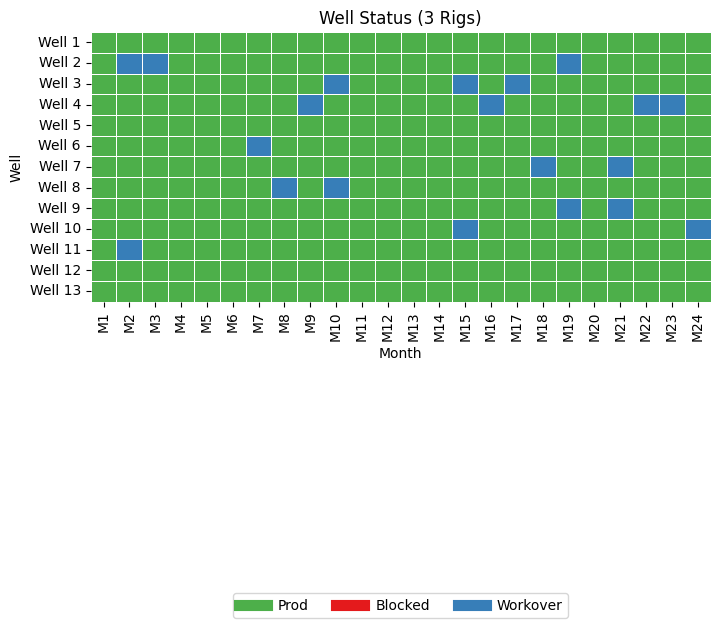

/tmp/ipykernel_986929/1636266121.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


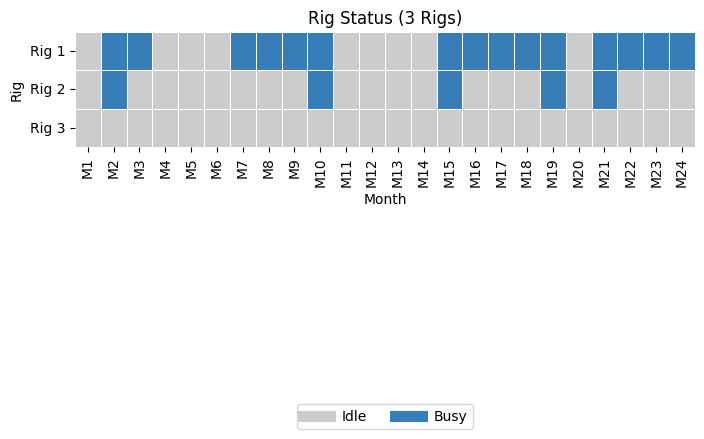

In [5]:
# --- Gráfico Gantt dos poços ---
from matplotlib.colors import ListedColormap

def plot_gantt(estados_pocos, titulo):
    plt.figure(figsize=(8,3.5))
    cmap = ListedColormap(cores_estados_poco)
    sns.heatmap(estados_pocos, cmap=cmap, cbar=False, linewidths=0.5)
    plt.yticks(np.arange(n_pocos)+0.5, [f'Well {i+1}' for i in range(n_pocos)], rotation=0)
    plt.xticks(np.arange(n_meses)+0.5, [f'M{m+1}' for m in range(n_meses)], rotation=90)
    plt.title(titulo)
    plt.xlabel('Month')
    plt.ylabel('Well')
    legend_elems = [plt.Line2D([0], [0], color=cor, lw=8) for cor in cores_estados_poco]
    plt.legend(legend_elems, list(ESTADOS_POCO.values()), ncol=len(ESTADOS_POCO), loc='lower center', bbox_to_anchor=(0.5, -1.2))
    plt.tight_layout()
    plt.show()

# Plot para o primeiro cenário
plot_gantt(cenarios[0]['estados'][0], 'Well Status (1 Rig)')

# --- Gráfico Gantt do uso das embarcações ---
def plot_gantt_emb(uso_embarcacao, titulo):
    plt.figure(figsize=(8,0+0.5*uso_embarcacao.shape[0]))
    cmap = ListedColormap(cores_embarcacao)
    sns.heatmap(uso_embarcacao, cmap=cmap, cbar=False, linewidths=0.5)
    plt.yticks(np.arange(uso_embarcacao.shape[0])+0.5, [f'Rig {i+1}' for i in range(uso_embarcacao.shape[0])], rotation=0)
    plt.xticks(np.arange(n_meses)+0.5, [f'M{m+1}' for m in range(n_meses)], rotation=90)
    plt.title(titulo)
    plt.xlabel('Month')
    plt.ylabel('Rig')
    legend_elems = [plt.Line2D([0], [0], color=cor, lw=8) for cor in cores_embarcacao]
    plt.legend(legend_elems, list(ESTADOS_EMB.values()), ncol=len(ESTADOS_EMB), loc='lower center', bbox_to_anchor=(0.5, -2.5))
    plt.tight_layout()
    plt.show()

plot_gantt_emb(cenarios[0]['uso_emb'][0], 'Rig Status (1 Rig)')

plot_gantt(cenarios[0]['estados'][1], 'Well Status (2 Rigs)')
plot_gantt_emb(cenarios[0]['uso_emb'][1], 'Rig Status (2 Rigs)')
plot_gantt(cenarios[0]['estados'][2], 'Well Status (3 Rigs)')
plot_gantt_emb(cenarios[0]['uso_emb'][2], 'Rig Status (3 Rigs)')

# Implementation with Fuzzy Prioritization

[4270997300.525694, 4329177717.435057, 4259230523.5278563]
[4160439731.417744, 4225326387.249847, 4049342551.2407517]
[4114904045.033541, 4087132833.164191, 3872501666.484166]
[4043842006.1663623, 3948140539.6925764, 3680813195.175016]


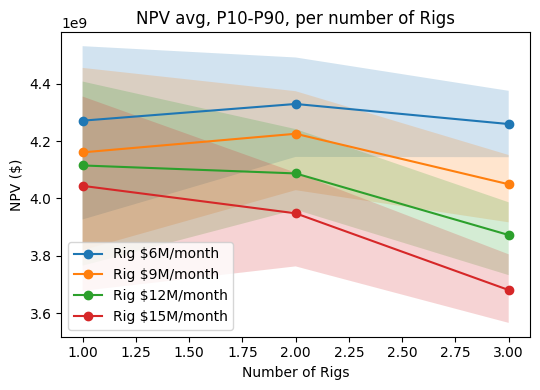

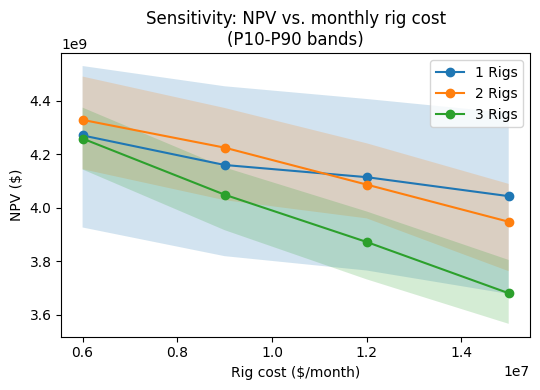

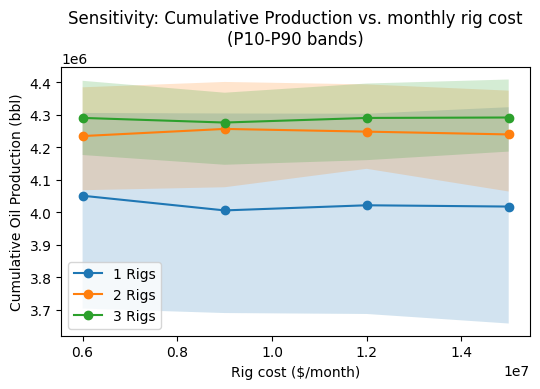

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Configurações iniciais
np.random.seed(2)
n_pocos = 13
n_meses = 24
n_simul = 100
taxa = 0.01 # taxa de desconto mensal
preco_oleo = 40 # $/bbl

# Coordenadas sintéticas dos poços (para cálculo do deslocamento)
coordenadas_pocos = np.random.uniform(0, 100, (n_pocos, 2))

# Curvas sintéticas de produção (vazão de óleo e water cut)
vazao_inicial = np.random.uniform(6500, 35000, n_pocos)
declinio = np.random.uniform(0.003, 0.025, n_pocos)
wc_inicial = np.random.uniform(0.0, 0.5, n_pocos)
wc_final = np.random.uniform(0.6, 0.85, n_pocos)

prod_oleo = np.zeros((n_pocos, n_meses))
water_cut = np.zeros((n_pocos, n_meses))
for i in range(n_pocos):
    prod_oleo[i] = vazao_inicial[i] * np.exp(-declinio[i]*np.arange(n_meses))
    water_cut[i] = np.linspace(wc_inicial[i], wc_final[i], n_meses)

def prob_bloqueio(wc):
    return wc/8

precos_embarcacao = [6000000, 9000000, 12000000, 15000000] # $/mês
meses_contrato = 12
prob_embarcacao = [0.75, 0.25] # 1 mês, 2 meses
tempo_embarcacao = [1, 2]

ESTADOS_POCO = {0: 'Prod', 1: 'Blocked', 2: 'Workover'}
cores_estados_poco = ['#4daf4a', '#e41a1c', '#377eb8']

ESTADOS_EMB = {0: 'Idle', 1: 'Busy'}
cores_embarcacao = ['#cccccc', '#377eb8']

# ------ Sistema fuzzy para priorização ------
prod_perdida = ctrl.Antecedent(np.arange(0, 54001, 1), 'prod_perdida')
water_cut_fz = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'water_cut')
tempo_espera_fz = ctrl.Antecedent(np.arange(0, 5, 1), 'tempo_espera')
tempo_desloc_fz = ctrl.Antecedent(np.arange(0, 141, 1), 'tempo_desloc') # maior distância possível no plano [0,100]

prioridade = ctrl.Consequent(np.arange(0, 11, 1), 'prioridade')

prod_perdida['baixa'] = fuzz.trimf(prod_perdida.universe, [0, 0, 18000])
prod_perdida['media'] = fuzz.trimf(prod_perdida.universe, [000, 18000, 36000])
prod_perdida['alta'] = fuzz.trimf(prod_perdida.universe, [18000, 36000, 54000])

water_cut_fz['baixo'] = fuzz.trimf(water_cut_fz.universe, [0, 0, 0.35])
water_cut_fz['medio'] = fuzz.trimf(water_cut_fz.universe, [0.15, 0.5, 0.85])
water_cut_fz['alto'] = fuzz.trimf(water_cut_fz.universe, [0.65, 1, 1])

tempo_espera_fz['curto'] = fuzz.trimf(tempo_espera_fz.universe, [0, 0, 1.4])
tempo_espera_fz['medio'] = fuzz.trimf(tempo_espera_fz.universe, [0.6, 2, 3.4])
tempo_espera_fz['longo'] = fuzz.trimf(tempo_espera_fz.universe, [2.6, 4, 4])

tempo_desloc_fz['curto'] = fuzz.trimf(tempo_desloc_fz.universe, [0, 0, 50])
tempo_desloc_fz['medio'] = fuzz.trimf(tempo_desloc_fz.universe, [20, 60, 100])
tempo_desloc_fz['longo'] = fuzz.trimf(tempo_desloc_fz.universe, [60, 140, 140])

prioridade['baixa'] = fuzz.trimf(prioridade.universe, [0, 0, 4])
prioridade['media'] = fuzz.trimf(prioridade.universe, [1, 5, 9])
prioridade['alta'] = fuzz.trimf(prioridade.universe, [6, 10, 10])


# Regras no scikit-fuzzy

# Caso 1
rule1 = ctrl.Rule(prod_perdida['alta'] | water_cut_fz['baixo'], prioridade['alta'])
rule2 = ctrl.Rule(prod_perdida['media'] & water_cut_fz['medio'], prioridade['alta'])
rule3 = ctrl.Rule(prod_perdida['media'] & water_cut_fz['alto'], prioridade['media'])
rule4 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['medio'], prioridade['media'])
rule5 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['alto'] & tempo_espera_fz['medio'] & tempo_desloc_fz['medio'], prioridade['media'])
rule6 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['alto'] & tempo_espera_fz['curto'] & tempo_desloc_fz['longo'], prioridade['baixa'])
prioridade_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6])

def calcular_tempo_desloc(emb_pos, poco_pos):
    # Distância euclidiana no plano
    return np.linalg.norm(emb_pos - poco_pos)

def simular(preco_embarcacao, n_embarcacoes):
    emb_contrato = [0]*n_embarcacoes
    emb_status = [None] * n_embarcacoes
    emb_posicoes = np.zeros((n_embarcacoes, 2))
    estados_pocos = np.zeros((n_pocos, n_meses), dtype=int)
    uso_embarcacao = np.zeros((n_embarcacoes, n_meses), dtype=int)
    manut_iniciada = [None]*n_pocos
    receitas = np.zeros(n_meses)
    custos = np.zeros(n_meses)
    estados_pocos[:,0] = 0
    for i in range(n_embarcacoes):
        emb_posicoes[i] = coordenadas_pocos[0]

    for mes in range(n_meses):
        for i in range(n_embarcacoes):
            if mes%meses_contrato==0:
                emb_contrato[i] = meses_contrato

        if mes > 0:
            estados_pocos[:,mes] = estados_pocos[:,mes-1]

        # Libera embarcações cujas manutenções terminaram
        for i in range(n_embarcacoes):
            if emb_status[i] is not None:
                poco, meses_rest = emb_status[i]
                uso_embarcacao[i,mes] = 1
                if meses_rest == 1:
                    emb_status[i] = None
                    manut_iniciada[poco] = None
                    estados_pocos[poco, mes] = 0
                    uso_embarcacao[i,mes] = 0
                    emb_posicoes[i] = coordenadas_pocos[poco]
                else:
                    emb_status[i] = (poco, meses_rest-1)

        for p in range(n_pocos):
            if estados_pocos[p,mes] == 0 and manut_iniciada[p] is None:
                if np.random.rand() < prob_bloqueio(water_cut[p,mes]):
                    estados_pocos[p,mes] = 1

        # PRIORIZAÇÃO FUZZY
        poços_bloqueados = [p for p in range(n_pocos) if estados_pocos[p, mes] == 1 and manut_iniciada[p] is None]
        prioridades = []
        for p in poços_bloqueados:
            meses_bloqueado = 1
            if mes > 0:
                i = mes-1
                while i >= 0 and estados_pocos[p, i] == 1:
                    meses_bloqueado += 1
                    i -= 1
            prod_perdida_val = prod_oleo[p, mes] #* 30 * meses_bloqueado
            water_cut_val = water_cut[p, mes]
            tempo_espera_val = meses_bloqueado
            emb_livres = [i for i in range(n_embarcacoes) if emb_status[i] is None and emb_contrato[i] > 0]
            if emb_livres:
                tempos_desloc_embs = [calcular_tempo_desloc(emb_posicoes[i], coordenadas_pocos[p]) for i in emb_livres]
                tempo_desloc_val = min(tempos_desloc_embs)
            else:
                tempo_desloc_val = tempo_desloc_fz.universe.max() # máximo

            # CLIPPING
            prod_perdida_val = np.clip(prod_perdida_val, prod_perdida.universe.min(), prod_perdida.universe.max())
            water_cut_val = np.clip(water_cut_val, water_cut_fz.universe.min(), water_cut_fz.universe.max())
            tempo_espera_val = np.clip(tempo_espera_val, tempo_espera_fz.universe.min(), tempo_espera_fz.universe.max())
            tempo_desloc_val = np.clip(tempo_desloc_val, tempo_desloc_fz.universe.min(), tempo_desloc_fz.universe.max())

            prioridade_fuzzy = ctrl.ControlSystemSimulation(prioridade_ctrl)
            prioridade_fuzzy.input['prod_perdida'] = prod_perdida_val
            prioridade_fuzzy.input['water_cut'] = water_cut_val
            prioridade_fuzzy.input['tempo_espera'] = tempo_espera_val
            prioridade_fuzzy.input['tempo_desloc'] = tempo_desloc_val
            try:
                prioridade_fuzzy.compute()
                prioridades.append(prioridade_fuzzy.output['prioridade'])
            except Exception as e:
                prioridades.append(0)

        # Alocação das embarcações
        poços_ordenados = [poços_bloqueados[i] for i in np.argsort(-np.array(prioridades))]
        emb_livres = [i for i in range(n_embarcacoes) if emb_status[i] is None and emb_contrato[i] > 0]
        if poços_ordenados and emb_livres:
            emb_livres_ord = sorted(
                emb_livres,
                key=lambda i: min([calcular_tempo_desloc(emb_posicoes[i], coordenadas_pocos[p]) for p in poços_ordenados])
            )
            for p in poços_ordenados:
                if emb_livres_ord:
                    emb_idx = emb_livres_ord.pop(0)
                    tempo = np.random.choice(tempo_embarcacao, p=prob_embarcacao)
                    emb_status[emb_idx] = (p, tempo)
                    manut_iniciada[p] = ('emb', emb_idx, tempo)
                    estados_pocos[p, mes] = 2
                    uso_embarcacao[emb_idx, mes] = 1
                    emb_posicoes[emb_idx] = coordenadas_pocos[p]
                else:
                    break

        receita_mes = 0
        for p in range(n_pocos):
            if estados_pocos[p,mes] == 0:
                receita_mes += prod_oleo[p,mes] * 30 * preco_oleo
        receitas[mes] = receita_mes
        custos[mes] = n_embarcacoes*preco_embarcacao
        for i in range(n_embarcacoes):
            emb_contrato[i] -= 1

    fluxo_liq = receitas-custos
    vpl = np.sum(fluxo_liq/((1+taxa)**np.arange(n_meses)))
    prod_acum = np.sum([np.sum(prod_oleo[p,:][estados_pocos[p,:]==0]) for p in range(n_pocos)])
    return vpl, estados_pocos, uso_embarcacao, prod_acum

# Simulações para diferentes cenários de embarcação
cenarios = []
for preco_embarcacao in precos_embarcacao:
    vpl_sim = []
    prodacum_sim = []
    estados_sim = []
    uso_emb_sim = []
    for n_embarcacoes in [1,2,3]:
        vpl_cen = []
        prodacum_cen = []
        for s in range(n_simul):
            vpl, estados_pocos, uso_embarcacao, prod_acum = simular(preco_embarcacao, n_embarcacoes)
            vpl_cen.append(vpl)
            prodacum_cen.append(prod_acum)
            if s==0:
                estados_sim.append(estados_pocos)
                uso_emb_sim.append(uso_embarcacao)
        vpl_sim.append(vpl_cen)
        prodacum_sim.append(prodacum_cen)
    cenarios.append({
        'preco': preco_embarcacao,
        'vpls': vpl_sim,
        'prodacum': prodacum_sim,
        'estados': estados_sim,
        'uso_emb': uso_emb_sim
    })

# --- Plots ---
plt.figure(figsize=(5.5,4))
for idx, c in enumerate(cenarios):
    vpls = c['vpls']
    vpl_medios = [np.mean(v) for v in vpls]
    vpl_p10 = [np.percentile(v, 10) for v in vpls]
    vpl_p90 = [np.percentile(v, 90) for v in vpls]
    print(vpl_medios)
    plt.plot([1,2,3], vpl_medios, marker='o', label=f'Rig ${c["preco"]/1000000:.0f}M/month')
    plt.fill_between([1,2,3], vpl_p10, vpl_p90, alpha=0.2)
plt.xlabel('Number of Rigs')
plt.ylabel('NPV ($)')
plt.title('NPV avg, P10-P90, per number of Rigs')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5,4))
for n in range(3):
    vpl_medios = [np.mean(c['vpls'][n]) for c in cenarios]
    vpl_p10 = [np.percentile(c['vpls'][n], 10) for c in cenarios]
    vpl_p90 = [np.percentile(c['vpls'][n], 90) for c in cenarios]
    plt.plot(precos_embarcacao, vpl_medios, marker='o', label=f'{n+1} Rigs')
    plt.fill_between(precos_embarcacao, vpl_p10, vpl_p90, alpha=0.2)
plt.xlabel('Rig cost ($/month)')
plt.ylabel('NPV ($)')
plt.title('Sensitivity: NPV vs. monthly rig cost\n(P10-P90 bands)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5,4))
for n in range(3):
    prodacum_medios = [np.mean(c['prodacum'][n]) for c in cenarios]
    prodacum_p10 = [np.percentile(c['prodacum'][n], 10) for c in cenarios]
    prodacum_p90 = [np.percentile(c['prodacum'][n], 90) for c in cenarios]
    plt.plot(precos_embarcacao, prodacum_medios, marker='o', label=f'{n+1} Rigs')
    plt.fill_between(precos_embarcacao, prodacum_p10, prodacum_p90, alpha=0.2)
plt.xlabel('Rig cost ($/month)')
plt.ylabel('Cumulative Oil Production (bbl)')
plt.title('Sensitivity: Cumulative Production vs. monthly rig cost\n(P10-P90 bands)')
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_986929/2370048176.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


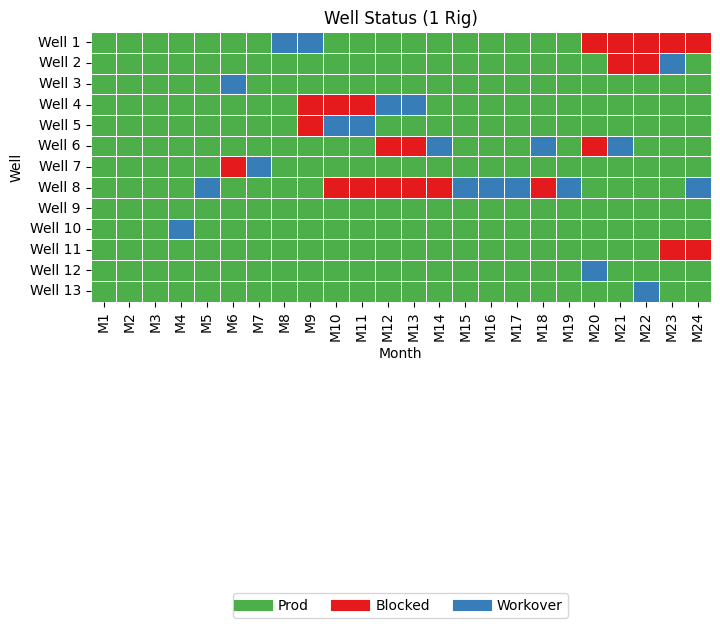

/tmp/ipykernel_986929/2370048176.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


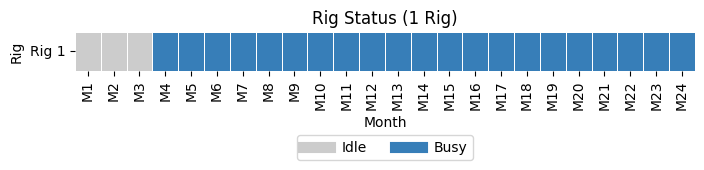

/tmp/ipykernel_986929/2370048176.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


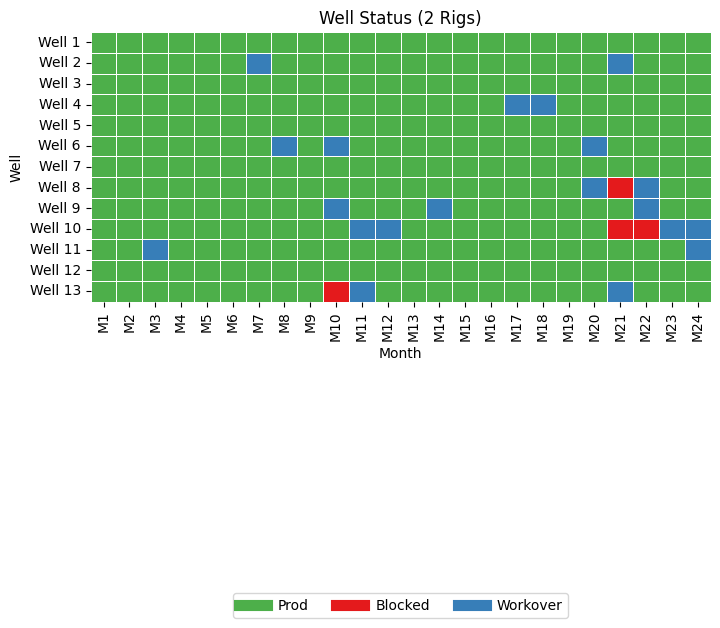

/tmp/ipykernel_986929/2370048176.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


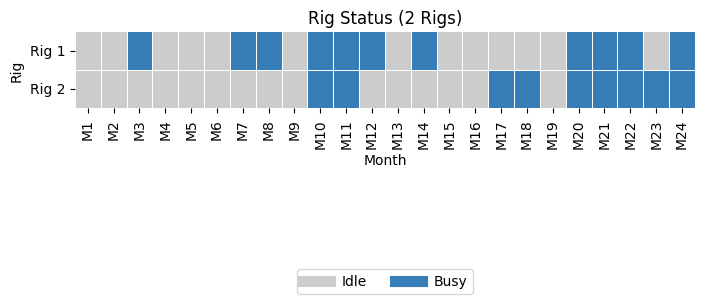

/tmp/ipykernel_986929/2370048176.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


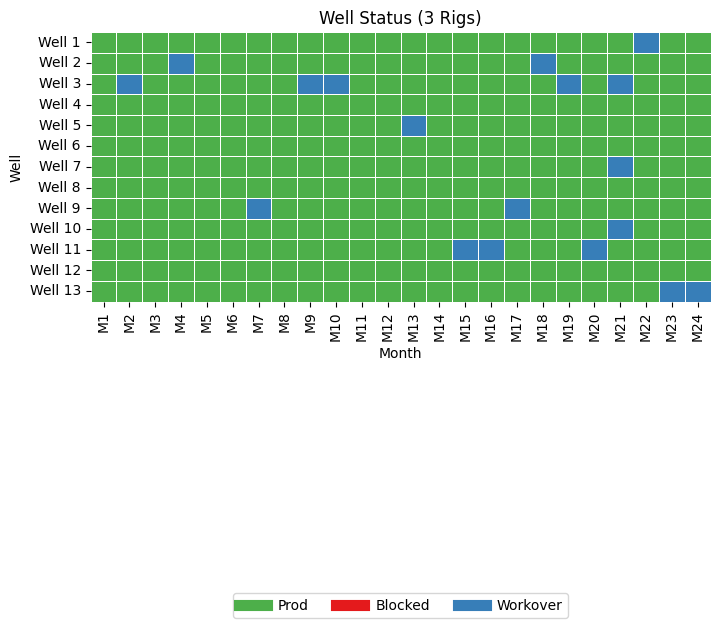

/tmp/ipykernel_986929/2370048176.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


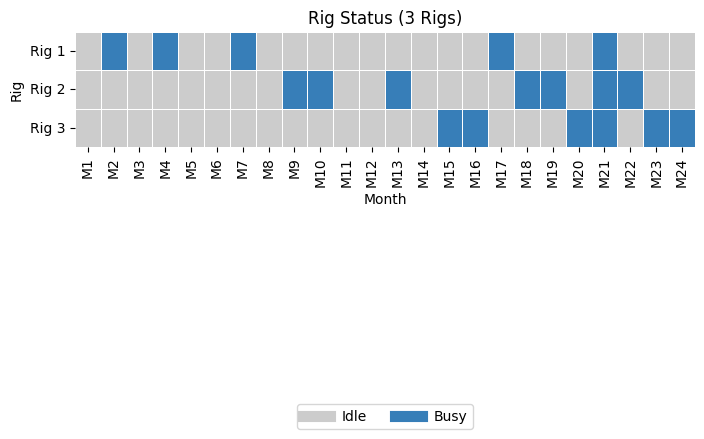

In [46]:
from matplotlib.colors import ListedColormap

def plot_gantt(estados_pocos, titulo):
    plt.figure(figsize=(8,3.5))
    cmap = ListedColormap(cores_estados_poco)
    sns.heatmap(estados_pocos, cmap=cmap, cbar=False, linewidths=0.5)
    plt.yticks(np.arange(n_pocos)+0.5, [f'Well {i+1}' for i in range(n_pocos)], rotation=0)
    plt.xticks(np.arange(n_meses)+0.5, [f'M{m+1}' for m in range(n_meses)], rotation=90)
    plt.title(titulo)
    plt.xlabel('Month')
    plt.ylabel('Well')
    legend_elems = [plt.Line2D([0], [0], color=cor, lw=8) for cor in cores_estados_poco]
    plt.legend(legend_elems, list(ESTADOS_POCO.values()), ncol=len(ESTADOS_POCO), loc='lower center', bbox_to_anchor=(0.5, -1.2))
    plt.tight_layout()
    plt.show()

# Plot para o primeiro cenário
plot_gantt(cenarios[0]['estados'][0], 'Well Status (1 Rig)')

# --- Gráfico Gantt do uso das embarcações ---
def plot_gantt_emb(uso_embarcacao, titulo):
    plt.figure(figsize=(8,0+0.5*uso_embarcacao.shape[0]))
    cmap = ListedColormap(cores_embarcacao)
    sns.heatmap(uso_embarcacao, cmap=cmap, cbar=False, linewidths=0.5)
    plt.yticks(np.arange(uso_embarcacao.shape[0])+0.5, [f'Rig {i+1}' for i in range(uso_embarcacao.shape[0])], rotation=0)
    plt.xticks(np.arange(n_meses)+0.5, [f'M{m+1}' for m in range(n_meses)], rotation=90)
    plt.title(titulo)
    plt.xlabel('Month')
    plt.ylabel('Rig')
    legend_elems = [plt.Line2D([0], [0], color=cor, lw=8) for cor in cores_embarcacao]
    plt.legend(legend_elems, list(ESTADOS_EMB.values()), ncol=len(ESTADOS_EMB), loc='lower center', bbox_to_anchor=(0.5, -2.5))
    plt.tight_layout()
    plt.show()

plot_gantt_emb(cenarios[0]['uso_emb'][0], 'Rig Status (1 Rig)')

plot_gantt(cenarios[0]['estados'][1], 'Well Status (2 Rigs)')
plot_gantt_emb(cenarios[0]['uso_emb'][1], 'Rig Status (2 Rigs)')
plot_gantt(cenarios[0]['estados'][2], 'Well Status (3 Rigs)')
plot_gantt_emb(cenarios[0]['uso_emb'][2], 'Rig Status (3 Rigs)')

In [41]:
# ------ Sistema fuzzy para priorização ------
prod_perdida = ctrl.Antecedent(np.arange(0, 54001, 1), 'prod_perdida')
water_cut_fz = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'water_cut')
tempo_espera_fz = ctrl.Antecedent(np.arange(0, 5, 0.1), 'tempo_espera')
tempo_desloc_fz = ctrl.Antecedent(np.arange(0, 141, 1), 'tempo_desloc') # maior distância possível no plano [0,100]

prioridade = ctrl.Consequent(np.arange(0, 11, 1), 'prioridade')

prod_perdida['baixa'] = fuzz.trimf(prod_perdida.universe, [0, 0, 18000])
prod_perdida['media'] = fuzz.trimf(prod_perdida.universe, [000, 18000, 36000])
prod_perdida['alta'] = fuzz.trapmf(prod_perdida.universe, [18000, 36000, 54000, 54000])

water_cut_fz['baixo'] = fuzz.trimf(water_cut_fz.universe, [0, 0, 0.4])
water_cut_fz['medio'] = fuzz.trimf(water_cut_fz.universe, [0, 0.4, 0.75])
water_cut_fz['alto'] = fuzz.trapmf(water_cut_fz.universe, [0.4, 0.75, 1, 1])

tempo_espera_fz['curto'] = fuzz.trimf(tempo_espera_fz.universe, [0, 0, 1.4])
tempo_espera_fz['medio'] = fuzz.trimf(tempo_espera_fz.universe, [0.6, 2, 3.4])
tempo_espera_fz['longo'] = fuzz.trapmf(tempo_espera_fz.universe, [2.6, 4, 5, 5])

tempo_desloc_fz['curto'] = fuzz.trimf(tempo_desloc_fz.universe, [0, 0, 50])
tempo_desloc_fz['medio'] = fuzz.trimf(tempo_desloc_fz.universe, [20, 60, 100])
tempo_desloc_fz['longo'] = fuzz.trimf(tempo_desloc_fz.universe, [60, 140, 140])

prioridade['baixa'] = fuzz.trimf(prioridade.universe, [0, 0, 5])
prioridade['media'] = fuzz.trimf(prioridade.universe, [0, 5, 10])
prioridade['alta'] = fuzz.trimf(prioridade.universe, [5, 10, 10])

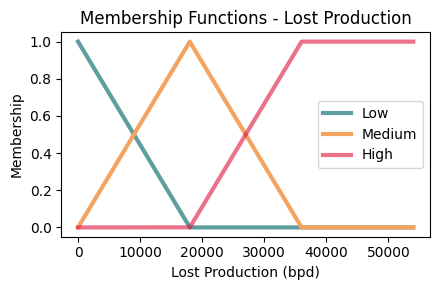

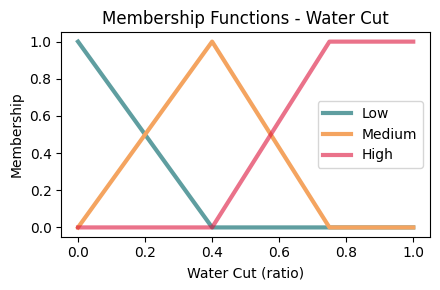

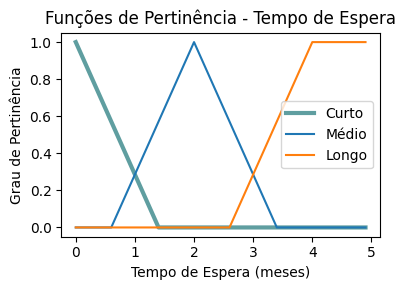

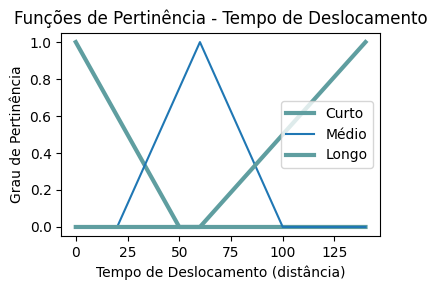

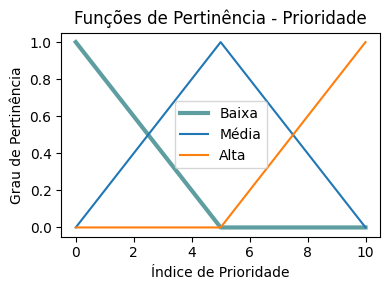

In [58]:
import matplotlib.pyplot as plt



# --- Produção Perdida ---
plt.figure(figsize=(4.5,3))
plt.plot(prod_perdida.universe, prod_perdida['baixa'].mf, label='Low', color='cadetblue', linewidth=3)
plt.plot(prod_perdida.universe, prod_perdida['media'].mf, label='Medium', color='sandybrown', linewidth=3)
plt.plot(prod_perdida.universe, prod_perdida['alta'].mf, label='High', color='crimson', linewidth=3, alpha=0.6)
plt.title('Membership Functions - Lost Production')
plt.xlabel('Lost Production (bpd)')
plt.ylabel('Membership')
plt.legend()
plt.tight_layout()
plt.show()

# --- Water Cut ---
plt.figure(figsize=(4.5,3))
plt.plot(water_cut_fz.universe, water_cut_fz['baixo'].mf, label='Low', color='cadetblue', linewidth=3)
plt.plot(water_cut_fz.universe, water_cut_fz['medio'].mf, label='Medium', color='sandybrown', linewidth=3)
plt.plot(water_cut_fz.universe, water_cut_fz['alto'].mf, label='High', color='crimson', linewidth=3, alpha=0.6)
plt.title('Membership Functions - Water Cut')
plt.xlabel('Water Cut (ratio)')
plt.ylabel('Membership')
plt.legend()
plt.tight_layout()
plt.show()

# --- Tempo de Espera ---
plt.figure(figsize=(4,3))
plt.plot(tempo_espera_fz.universe, tempo_espera_fz['curto'].mf, label='Curto', color='cadetblue', linewidth=3)
plt.plot(tempo_espera_fz.universe, tempo_espera_fz['medio'].mf, label='Médio')
plt.plot(tempo_espera_fz.universe, tempo_espera_fz['longo'].mf, label='Longo')
plt.title('Funções de Pertinência - Tempo de Espera')
plt.xlabel('Tempo de Espera (meses)')
plt.ylabel('Grau de Pertinência')
plt.legend()
plt.tight_layout()
plt.show()

# --- Tempo de Deslocamento ---
plt.figure(figsize=(4,3))
plt.plot(tempo_desloc_fz.universe, tempo_desloc_fz['curto'].mf, label='Curto', color='cadetblue', linewidth=3)
plt.plot(tempo_desloc_fz.universe, tempo_desloc_fz['medio'].mf, label='Médio')
plt.plot(tempo_desloc_fz.universe, tempo_desloc_fz['longo'].mf, label='Longo', color='cadetblue', linewidth=3)
plt.title('Funções de Pertinência - Tempo de Deslocamento')
plt.xlabel('Tempo de Deslocamento (distância)')
plt.ylabel('Grau de Pertinência')
plt.legend()
plt.tight_layout()
plt.show()

# --- Prioridade ---
plt.figure(figsize=(4,3))
plt.plot(prioridade.universe, prioridade['baixa'].mf, label='Baixa', color='cadetblue', linewidth=3)
plt.plot(prioridade.universe, prioridade['media'].mf, label='Média')
plt.plot(prioridade.universe, prioridade['alta'].mf, label='Alta')
plt.title('Funções de Pertinência - Prioridade')
plt.xlabel('Índice de Prioridade')
plt.ylabel('Grau de Pertinência')
plt.legend()
plt.tight_layout()
plt.show()


In [76]:
# ------ Sistema fuzzy para priorização ------
prod_perdida = ctrl.Antecedent(np.arange(0, 54001, 1), 'prod_perdida')
water_cut_fz = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'water_cut')
tempo_espera_fz = ctrl.Antecedent(np.arange(0, 5, 1), 'tempo_espera')
tempo_desloc_fz = ctrl.Antecedent(np.arange(0, 141, 1), 'tempo_desloc') # maior distância possível no plano [0,100]

prioridade = ctrl.Consequent(np.arange(0, 11, 1), 'prioridade')

prod_perdida['baixa'] = fuzz.trimf(prod_perdida.universe, [0, 0, 18000])
prod_perdida['media'] = fuzz.trimf(prod_perdida.universe, [000, 18000, 36000])
prod_perdida['alta'] = fuzz.trimf(prod_perdida.universe, [18000, 36000, 54000])

water_cut_fz['baixo'] = fuzz.trimf(water_cut_fz.universe, [0, 0, 0.35])
water_cut_fz['medio'] = fuzz.trimf(water_cut_fz.universe, [0.15, 0.5, 0.85])
water_cut_fz['alto'] = fuzz.trimf(water_cut_fz.universe, [0.65, 1, 1])

tempo_espera_fz['curto'] = fuzz.trimf(tempo_espera_fz.universe, [0, 0, 1.4])
tempo_espera_fz['medio'] = fuzz.trimf(tempo_espera_fz.universe, [0.6, 2, 3.4])
tempo_espera_fz['longo'] = fuzz.trimf(tempo_espera_fz.universe, [2.6, 4, 4])

tempo_desloc_fz['curto'] = fuzz.trimf(tempo_desloc_fz.universe, [0, 0, 50])
tempo_desloc_fz['medio'] = fuzz.trimf(tempo_desloc_fz.universe, [20, 60, 100])
tempo_desloc_fz['longo'] = fuzz.trimf(tempo_desloc_fz.universe, [60, 140, 140])

prioridade['baixa'] = fuzz.trimf(prioridade.universe, [0, 0, 4])
prioridade['media'] = fuzz.trimf(prioridade.universe, [1, 5, 9])
prioridade['alta'] = fuzz.trimf(prioridade.universe, [6, 10, 10])

rule1 = ctrl.Rule(prod_perdida['alta'], prioridade['alta'])
rule2 = ctrl.Rule((water_cut_fz['baixo'] | water_cut_fz['medio']) & (tempo_espera_fz['longo'] | tempo_espera_fz['medio']) & prod_perdida['media'], prioridade['alta'])
rule3 = ctrl.Rule(prod_perdida['media'] & water_cut_fz['alto'] & tempo_espera_fz['curto'] & tempo_desloc_fz['longo'], prioridade['media'])
rule4 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['medio'] & tempo_espera_fz['medio'] & tempo_desloc_fz['medio'], prioridade['media'])
rule5 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['alto'] & tempo_espera_fz['curto'] & tempo_desloc_fz['longo'], prioridade['baixa'])
prioridade_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])


In [77]:
rule1 = ctrl.Rule(prod_perdida['alta'] | water_cut_fz['baixo'], prioridade['alta'])
rule2 = ctrl.Rule(prod_perdida['media'] & water_cut_fz['medio'], prioridade['alta'])
rule3 = ctrl.Rule(prod_perdida['media'] & water_cut_fz['alto'], prioridade['media'])
rule4 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['medio'], prioridade['media'])
rule5 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['alto'] & tempo_espera_fz['medio'] & tempo_desloc_fz['medio'], prioridade['media'])
rule6 = ctrl.Rule(prod_perdida['baixa'] & water_cut_fz['alto'] & tempo_espera_fz['curto'] & tempo_desloc_fz['longo'], prioridade['baixa'])

<bound method Rule.view of IF ((water_cut[baixo] OR water_cut[medio]) AND (tempo_espera[longo] OR tempo_espera[medio])) AND prod_perdida[media] THEN prioridade[alta]
	AND aggregation function : fmin
	OR aggregation function  : fmax>

In [38]:
from graphviz import Digraph

In [46]:
dot = Digraph(comment='Methodology Flowchart')

# Configuração global dos nós
node_style = {'shape': 'box', 'style': 'rounded,filled', 'fillcolor': '#EFF7FF', 'color': '#377eb8'}

dot.node('A', 'Start', **node_style)
dot.node('B', 'Synthetic Well Data Generation', **node_style)
dot.node('C', 'Model Parameter Initialization', **node_style)
dot.node('D', 'Monthly Simulation (Loop)', **node_style)
dot.node('E', 'Well State Update', **node_style)
dot.node('F', 'Blockage Event Assessment', **node_style)
dot.node('G', 'Identification of Blocked Wells', **node_style)
dot.node('H', 'Fuzzy Prioritization System', **node_style)
dot.node('I', 'Allocation of Available Vessels', **node_style)
dot.node('J', 'Update of Vessel and Well States', **node_style)
dot.node('K', 'Revenue, Cost, NPV and Cumulative Production Calculation', **node_style)
dot.node('L', 'End', **node_style)

# Fluxo principal
dot.edges(['AB', 'BC', 'CD'])
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')
dot.edge('H', 'I')
dot.edge('I', 'J')
dot.edge('J', 'K')
dot.edge('K', 'L')

# Loop do mês para simulação mensal
dot.edge('K', 'D', label='Next Month', style='dashed', color='gray', constraint='false')

# Loop do Monte Carlo para nova simulação
dot.edge('L', 'B', label='Monte Carlo Iteration', style='dashed', color='gray', constraint='false')

dot.attr(rankdir='TB', size='8,10')  # Top-to-bottom, tamanho ajustável

dot.render('methodology_flowchart', format='png')

'methodology_flowchart.png'

In [ ]:
import openpyxl

def exportar_simulacao_excel(resultado, filename='simulacao_detalhada.xlsx'):
    """
    Exporta os resultados detalhados de uma simulação para Excel.
    
    Parâmetros:
    -----------
    resultado : dict
        Dicionário a ser retornado por simular()
        Deve conter: 'estados', 'eficiencia', 'uso_emb', etc.
    filename : str
        Nome do arquivo Excel de saída
    """
    
    estados_pocos = resultado['estados']
    eficiencia_pocos = resultado['eficiencia']
    uso_embarcacao = resultado['uso_emb']
    
    n_pocos = estados_pocos.shape[0]
    n_meses = estados_pocos.shape[1]
    n_embarcacoes = uso_embarcacao.shape[0]
    
    data = {'Mes': list(range(1, n_meses + 1))}
    
    for p in range(n_pocos):
        # Produção efetiva = produção base × eficiência
        prod_efetiva = [prod_oleo[p, m] * eficiencia_pocos[p, m] for m in range(n_meses)]
        data[f'Prod_W{p+1:02d}_bbl'] = prod_efetiva
    
    for p in range(n_pocos):
        data[f'Efic_W{p+1:02d}_%'] = [eficiencia_pocos[p, m] * 100 for m in range(n_meses)]
 
        data[f'WC_W{p+1:02d}_%'] = [water_cut[p, m] * 100 for m in range(n_meses)]

    status_map = {0: 'Producing', 1: 'Blocked', 2: 'Maintenance'}
    
    for p in range(n_pocos):
        data[f'Status_W{p+1:02d}'] = [status_map[estados_pocos[p, m]] for m in range(n_meses)]
    
    sonda_status_map = {0: 'Idle', 1: 'Busy'}
    
    for s in range(n_embarcacoes):
        data[f'Rig_{s+1}_Status'] = [sonda_status_map[uso_embarcacao[s, m]] for m in range(n_meses)]
    
    df = pd.DataFrame(data)
    df.to_excel(filename, index=False, sheet_name='Simulation Results')
    
    return filename